# Diva 01 RUNX3-dID Clone 13

This notebook details flow cytometry analysis for Diva01.

## Initialize Environment

In [1]:
# Load Packages
library(fcexpr)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggpubr)
library(ggsci)
library(stringr)
library(jsonlite)


Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Warning message:
“package ‘jsonlite’ was built under R version 4.4.3”


In [2]:
# Set Working Directory
setwd("/home/dalbao/AlbaoRunx3Manuscript/flow/Fig06")

# Load flow processing functions
source("/home/dalbao/AlbaoRunx3Manuscript/flow/scripts/flowProcessing.R")

# Import sample codebook
codebook <- read.csv("Diva01-Samples.csv")

# Population schemas file
p.schemas <- "Diva01-PopulationSchemas.json"

# Design schemas file
d.schemas <- "Diva05-DesignSchemas.json"

# Output Folder
output_folder <- "Diva01"

# Load Workspace (or cached version if it exists)
workspace <- load_workspace_cached(
                wsp_file = "DSE1-D8P1-Dominic-260825.wsp",
                rds_file = "Diva01-Workspace.rds",
                overwrite = FALSE # Set to TRUE to reprocess WSP and overwrite cached workspace
        )

# Extract Counts and MFI
counts  <- workspace[["counts"]]
stats   <- workspace[["stats"]]


Attaching package: ‘rlang’




The following objects are masked from ‘package:jsonlite’:

    flatten, unbox





Attaching package: ‘rstatix’




The following object is masked from ‘package:stats’:

    filter





Attaching package: ‘purrr’




The following objects are masked from ‘package:rlang’:

    %@%, flatten, flatten_chr, flatten_dbl, flatten_int, flatten_lgl,
    flatten_raw, invoke, splice




The following object is masked from ‘package:jsonlite’:

    flatten




# Process Gating Data
Cleanup data to report only gates below CD8.

In [3]:
# Filter only samples in "Samples" FlowJoGroup
surface <- counts %>% filter((FlowJoGroup %in% c("Samples")))

# Replace %20 in FileName with " "
surface <- surface %>%
    mutate(FileName = gsub("%20", " ", FileName))

# codebook contains a mapping of FileName metadata
# Join surface with codebook to get metadata
surface <- surface %>%
    left_join(  codebook,
                by = c("FileName" = "FileName"))

# Multiply FractionOfParent by 100 and rename to Percent
surface <- surface %>%
    mutate(FractionOfParent = FractionOfParent * 100) %>%
    rename(Percent = FractionOfParent)

head(surface)


,FileName,PopulationFullPath,Parent,Population,Count,ParentCount,Percent,xDim,yDim,eventsInside,FilePath,FlowJoGroup,ws,Group,Vector,TotalLymphocytes
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
1,Samples_EV 1.fcs,root,NA,root,1409414,NA,NA,NA,NA,NA,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/Diva%20Experiments/Exp1%20Runx3IDClone13/Flow/D8P1/Samples_EV%201.fcs,Samples,DSE1-D8P1-Dominic-260825.wsp,A,mock,36000000
2,Samples_EV 1.fcs,Lymphocytes,root,Lymphocytes,1281031,1409414,90.891037,FSC-A,SSC-A,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/Diva%20Experiments/Exp1%20Runx3IDClone13/Flow/D8P1/Samples_EV%201.fcs,Samples,DSE1-D8P1-Dominic-260825.wsp,A,mock,36000000
3,Samples_EV 1.fcs,Lymphocytes/Single Cells,Lymphocytes,Lymphocytes/Single Cells,1156227,1281031,90.257535,FSC-W,FSC-H,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/Diva%20Experiments/Exp1%20Runx3IDClone13/Flow/D8P1/Samples_EV%201.fcs,Samples,DSE1-D8P1-Dominic-260825.wsp,A,mock,36000000
4,Samples_EV 1.fcs,Lymphocytes/Single Cells/Single Cells,Lymphocytes/Single Cells,Single Cells/Single Cells,1111032,1156227,96.091165,SSC-W,SSC-H,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/Diva%20Experiments/Exp1%20Runx3IDClone13/Flow/D8P1/Samples_EV%201.fcs,Samples,DSE1-D8P1-Dominic-260825.wsp,A,mock,36000000
5,Samples_EV 1.fcs,Lymphocytes/Single Cells/Single Cells/CD8,Lymphocytes/Single Cells/Single Cells,CD8,192708,1111032,17.344955,Comp-BB790-A,Comp-BUV 396-A,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/Diva%20Experiments/Exp1%20Runx3IDClone13/Flow/D8P1/Samples_EV%201.fcs,Samples,DSE1-D8P1-Dominic-260825.wsp,A,mock,36000000
6,Samples_EV 1.fcs,Lymphocytes/Single Cells/Single Cells/CD8/Transferred,Lymphocytes/Single Cells/Single Cells/CD8,Transferred,4007,192708,2.079312,Comp-BUV496-A,SSC-A,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/Diva%20Experiments/Exp1%20Runx3IDClone13/Flow/D8P1/Samples_EV%201.fcs,Samples,DSE1-D8P1-Dominic-260825.wsp,A,mock,36000000


Process df:

In [4]:
# Keep only observations in surface wherin PopulationFullPath contains
# "Lymphocytes/Single Cells/Single Cells/"
surface <- surface %>%
    filter(grepl("Lymphocytes/Single Cells/Single Cells/", PopulationFullPath))

# Remove "Lymphocytes/Single Cells/Single Cells/" from PopulationFullPath
surface <- surface %>%
    mutate(PopulationFullPath = gsub("Lymphocytes/Single Cells/Single Cells/", "", PopulationFullPath))

# Select relevant columns
surface <- surface %>%
    # Rename FileName to ID, remove spaces
    mutate(ID = FileName) %>%
    select(ID, colnames(codebook), PopulationFullPath, TotalLymphocytes, Count, Percent) %>%
    select(-FileName)

Calculate total percent:

In [5]:
# First Compote Total Percent
total_percent <- compute_percent_of_total(surface) %>%
    mutate(PopulationString = PopulationFullPath)

# Make function relevel which "relevels" the total_percent dataframe
relevel_df <- function(df, base_level) {
    depth_subtract <- length(unlist(strsplit(base_level, "/")))
    df <- df %>%
        filter(grepl(paste0(base_level, "/"), PopulationFullPath)) %>%
        mutate(
            PopulationFullPath = gsub(paste0(base_level, "/"), "", PopulationFullPath),
            ParentPath = gsub(paste0(base_level), "", ParentPath),
            Depth = Depth - depth_subtract
        ) %>%
        # Remove "/" from ParentPath if it is first character
        mutate(ParentPath = gsub("^/", "", ParentPath))
    return(df)
}

# Collapse NaiveTransfer and ActivatedTransfer into Transfer
total_percent$PopulationFullPath <- gsub("Naive|Activated", "", total_percent$PopulationFullPath)

# Keep only if PopulationFullPath contains "CD8/Transferred/"
total_percent <- relevel_df(total_percent, "CD8/Transferred/Transfer")

# Extract transduction condition from PopulationFullPath and add as new column
total_percent$Transduction <- sapply(
    total_percent$PopulationFullPath,
    function(x) {
        split_path <- unlist(strsplit(x, "/"))
        return(split_path[1])
    }
)

# Remove ancillary columns and rename
total_percent <- total_percent %>%
    select(ID, Group, Vector, Transduction, PopulationString, PopulationFullPath, TotalLymphocytes, Count, Percent, PercentOfTotal, Depth) %>%
    rename(PercentOfLymphocytes = PercentOfTotal) %>%
    mutate(Percent = ifelse(Depth == 1, 100, Percent)) %>%
    select(-Depth) %>%
    mutate(PopulationFullPath = gsub("Double|OE|shRNA", "Transduced", PopulationFullPath))

# ---------------------------------------------------------------------
# Combine mutually exclusive Kaech gates into derived Marker populations.
# Kaech gating is a KLRG1 x CD127 double gate:
#   TE = KLRG1+CD127-, DP = KLRG1+CD127+, MP = KLRG1-CD127+, EE = KLRG1-CD127-
#   KLRG1pos = TE + DP ; CD127pos = DP + MP
# This workspace has no subgates under TE/DP/MP/EE, so only the
# top-level Kaech gates are combined (no CXCR6Pos/Tcf1Pos/ToxPos subgate
# combining, unlike other Diva notebooks).
# ---------------------------------------------------------------------
kaech_combinations <- list(
    list(resultingPath = "KLRG1pos", Path1 = "Kaech-TE", Path2 = "Kaech-DP"),
    list(resultingPath = "CD127pos", Path1 = "Kaech-DP", Path2 = "Kaech-MP")
)

# Percent (percent-of-immediate-parent) combines via combinePercents():
# top-level percents are summed. combinePercents operates on wide format
# (one column per PopulationFullPath), so pivot Percent wide first.
# A gate with 0 events reports Percent = NA (0/0 undefined) rather than
# 0; coalesce those to 0 here so a single empty branch doesn't wipe out
# an otherwise well-defined combination via NA propagation.
percent_wide <- total_percent %>%
    select(ID, Group, Vector, TotalLymphocytes, PopulationFullPath, Percent) %>%
    pivot_wider(names_from = PopulationFullPath, values_from = Percent) %>%
    mutate(across(-c(ID, Group, Vector, TotalLymphocytes), ~ replace_na(.x, 0)))

new_paths <- character(0)
for (td in c("Transduced", "Untransduced")) {
    for (combo in kaech_combinations) {
        percent_wide <- combinePercents(
            percent_wide,
            resultingPath = combo$resultingPath,
            Path1 = combo$Path1,
            Path2 = combo$Path2,
            constantPath = paste0(td, "/"),
            subsets = character(0)
        )
        new_paths <- c(new_paths, paste0(td, "/", combo$resultingPath))
    }
}

combined_percent <- percent_wide %>%
    select(ID, all_of(new_paths)) %>%
    pivot_longer(cols = all_of(new_paths), names_to = "PopulationFullPath", values_to = "Percent")

# Count and PercentOfLymphocytes are both already normalized to the same
# denominator (TotalLymphocytes), so unlike Percent they combine by plain
# summation. As above, a 0-count branch reports PercentOfLymphocytes = NA
# rather than 0, so coalesce before summing.
combine_by_sum <- function(df, resultingPath, Path1, Path2) {
    df <- df %>% mutate(GateSuffix = sub("^[^/]+/", "", PopulationFullPath))
    p1 <- df %>% filter(GateSuffix == Path1)
    p2 <- df %>% filter(GateSuffix == Path2)
    inner_join(
        p1, p2,
        by = c("ID", "Group", "Vector", "Transduction", "TotalLymphocytes"),
        suffix = c(".1", ".2")
    ) %>%
        transmute(
            ID, Group, Vector, Transduction, TotalLymphocytes,
            PopulationFullPath = paste0(Transduction, "/", resultingPath),
            Count = coalesce(Count.1, 0) + coalesce(Count.2, 0),
            PercentOfLymphocytes = coalesce(PercentOfLymphocytes.1, 0) + coalesce(PercentOfLymphocytes.2, 0)
        )
}

combined_counts <- bind_rows(lapply(kaech_combinations, function(combo) {
    combine_by_sum(total_percent, combo$resultingPath, combo$Path1, combo$Path2)
}))

# Merge Count/PercentOfLymphocytes with the combined Percent, and append
# the new derived populations to total_percent
combined_rows <- combined_counts %>%
    left_join(
        combined_percent %>% select(ID, PopulationFullPath, Percent),
        by = c("ID", "PopulationFullPath")
    ) %>%
    mutate(PopulationString = PopulationFullPath)

total_percent <- bind_rows(total_percent, combined_rows)

# Split total_percent into a list of dataframes based on "Transduction" column, with the names of the list being the unique values of "Transduction"
total_percent <- split(total_percent, total_percent$Transduction) %>%
    lapply(compute_percent_of_total) %>%
    bind_rows() %>%
    rename(PercentOfTransduced = PercentOfTotal) %>%
    add_population_derivatives() %>%
    finalize_flow_table(round_digits = NULL) %>%
    select(-Population) %>%
    mutate(
        RealCount = TotalLymphocytes * PercentOfLymphocytes / 100,
        Population = ifelse(is.na(Population1Deriv), "all", Population1Deriv)
    ) %>% select(-Population1Deriv)

head(total_percent, n = 10)

ID,Group,Vector,Transduction,PopulationString,TotalLymphocytes,Count,PercentOfLymphocytes,PercentOfTransduced,Percent,RealCount,Population
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Samples_EV 1.fcs,A,mock,Transduced,CD8/Transferred/ActivatedTransfer/Transduced,36000000,2091,0.188203400,100.000000,100.000000,67753.2240,all
Samples_EV 1.fcs,A,mock,Transduced,Transduced/CD127pos,36000000,56,0.005040359,2.678144,2.678144,1814.5292,CD127pos
Samples_EV 1.fcs,A,mock,Transduced,CD8/Transferred/ActivatedTransfer/Transduced/Gerlach-Tcm,36000000,354,0.031862269,16.929699,16.929699,11470.4167,Gerlach-Tcm
Samples_EV 1.fcs,A,mock,Transduced,CD8/Transferred/ActivatedTransfer/Transduced/Gerlach-Tem,36000000,40,0.003600256,1.912960,1.912960,1296.0923,Gerlach-Tem
Samples_EV 1.fcs,A,mock,Transduced,CD8/Transferred/ActivatedTransfer/Transduced/Gerlach-Tpm,36000000,1610,0.144910318,76.996652,76.996652,52167.7143,Gerlach-Tpm
Samples_EV 1.fcs,A,mock,Transduced,Transduced/KLRG1pos,36000000,824,0.074165281,39.406982,39.406982,26699.5010,KLRG1pos
Samples_EV 1.fcs,A,mock,Transduced,CD8/Transferred/ActivatedTransfer/Transduced/Kaech-DP,36000000,23,0.002070147,1.099952,1.099952,745.2531,Kaech-DP
Samples_EV 1.fcs,A,mock,Transduced,CD8/Transferred/ActivatedTransfer/Transduced/Kaech-EE,36000000,1234,0.111067908,59.014825,59.014825,39984.4469,Kaech-EE
Samples_EV 1.fcs,A,mock,Transduced,CD8/Transferred/ActivatedTransfer/Transduced/Kaech-MP,36000000,33,0.002970211,1.578192,1.578192,1069.2761,Kaech-MP


## Process MFI Data

In [6]:
mfi <- stats %>%
    # Keep only relevant columns in stats
    select(FileName, PopulationFullPath, channel, value) %>%
    # Relevel PopulationFullPath to "CD8"
    mutate(
        FileName = gsub("%20", " ", FileName),
        PopulationFullPath = gsub("Lymphocytes/Single Cells/Single Cells/", "", PopulationFullPath)) %>%
    # Rename channels
    mutate(channel = case_when(
        channel == "Comp-FITC-A" ~ "mfi.TCF1",
        channel == "Comp-APC-A" ~ "mfi.TOX",
        channel == "Comp-BV786-A" ~ "mfi.PD1")
    ) %>%
    # Pivot wider to have one row per FileName and PopulationFullPath, with columns for each channel
    pivot_wider(names_from = channel, values_from = value)

head(mfi)

FileName,PopulationFullPath,mfi.TOX,mfi.PD1,mfi.TCF1
<chr>,<chr>,<dbl>,<dbl>,<dbl>
Concat_E.fcs,CD8/Transferred/ActivatedTransfer/Transduced,2222.0662,2722.785,150.8873
Concat_E.fcs,CD8/Transferred/ActivatedTransfer/Transduced/Gerlach-Tcm,3003.7766,3188.278,422.2392
Concat_E.fcs,CD8/Transferred/ActivatedTransfer/Transduced/Gerlach-Tem,802.6764,1517.678,101.6908
Concat_E.fcs,CD8/Transferred/ActivatedTransfer/Transduced/Gerlach-Tpm,2178.1345,2706.453,111.0623
Concat_E.fcs,CD8/Transferred/ActivatedTransfer/Transduced/Kaech-DP,2677.4285,3701.996,345.3890
Concat_E.fcs,CD8/Transferred/ActivatedTransfer/Transduced/Kaech-EE,2276.8977,2621.945,127.6592


In [7]:
# Combine mfi (FileName, PopulationFullPath) to total_percent (ID, PopulationString)
all.data <- total_percent %>%
    left_join(mfi, by = c("ID" = "FileName", "PopulationString" = "PopulationFullPath")) %>%
    # Select columns
    select(
        ID, Group, Vector, Transduction,
        Population,
        Count, RealCount, PercentOfLymphocytes, PercentOfTransduced, Percent, mfi.TOX, mfi.PD1, mfi.TCF1
    )

head(all.data, n = 20)

ID,Group,Vector,Transduction,Population,Count,RealCount,PercentOfLymphocytes,PercentOfTransduced,Percent,mfi.TOX,mfi.PD1,mfi.TCF1
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Samples_EV 1.fcs,A,mock,Transduced,all,2091,67753.2240,0.1882034001,100.000000,100.000000,909.3185,2153.269,119.0185
Samples_EV 1.fcs,A,mock,Transduced,CD127pos,56,1814.5292,0.0050403589,2.678144,2.678144,NA,NA,NA
Samples_EV 1.fcs,A,mock,Transduced,Gerlach-Tcm,354,11470.4167,0.0318622686,16.929699,16.929699,1077.2245,2900.185,141.6259
Samples_EV 1.fcs,A,mock,Transduced,Gerlach-Tem,40,1296.0923,0.0036002563,1.912960,1.912960,349.4329,1239.960,103.7656
Samples_EV 1.fcs,A,mock,Transduced,Gerlach-Tpm,1610,52167.7143,0.1449103176,76.996652,76.996652,914.3433,2129.807,113.3368
Samples_EV 1.fcs,A,mock,Transduced,KLRG1pos,824,26699.5010,0.0741652806,39.406982,39.406982,NA,NA,NA
Samples_EV 1.fcs,A,mock,Transduced,Kaech-DP,23,745.2531,0.0020701474,1.099952,1.099952,579.8795,2083.301,126.8764
Samples_EV 1.fcs,A,mock,Transduced,Kaech-EE,1234,39984.4469,0.1110679080,59.014825,59.014825,973.6239,2023.112,118.2810
Samples_EV 1.fcs,A,mock,Transduced,Kaech-MP,33,1069.2761,0.0029702115,1.578192,1.578192,1478.8955,3604.895,255.5805


In [8]:
# ---------------------------------------------------------------------
# Combine geometric-mean MFI values for the derived KLRG1pos/CD127pos
# populations created in the total_percent step above. FlowJo reports
# a per-population geometric mean; combining two populations' geometric
# means (weighted by each population's own event Count) must be done in
# log scale to avoid overflow:
#   combined_gMean = exp( (n1*ln(gMean1) + n2*ln(gMean2)) / (n1+n2) )
# ---------------------------------------------------------------------
combine_gmean <- function(mfi1, mfi2, n1, n2) {
    # A branch with 0 events (or too few for FlowJo to report a gMean)
    # has NA mfi; 0*NA is NA in R, so it can't just be weighted in as
    # usual. Fall back to whichever branch is actually usable.
    case_when(
        is.na(mfi1) & is.na(mfi2) ~ NA_real_,
        is.na(mfi1) ~ mfi2,
        is.na(mfi2) ~ mfi1,
        TRUE ~ exp((n1 * log(mfi1) + n2 * log(mfi2)) / (n1 + n2))
    )
}

combine_mfi <- function(df, resultingPop, Pop1, Pop2) {
    p1 <- df %>% filter(Population == Pop1)
    p2 <- df %>% filter(Population == Pop2)
    inner_join(
        p1, p2,
        by = c("ID", "Group", "Vector", "Transduction"),
        suffix = c(".1", ".2")
    ) %>%
        transmute(
            ID, Group, Vector, Transduction,
            Population = resultingPop,
            mfi.TOX  = combine_gmean(mfi.TOX.1,  mfi.TOX.2,  Count.1, Count.2),
            mfi.PD1  = combine_gmean(mfi.PD1.1,  mfi.PD1.2,  Count.1, Count.2),
            mfi.TCF1 = combine_gmean(mfi.TCF1.1, mfi.TCF1.2, Count.1, Count.2)
        )
}

combined_mfi <- bind_rows(
    combine_mfi(all.data, "KLRG1pos", "Kaech-TE", "Kaech-DP"),
    combine_mfi(all.data, "CD127pos", "Kaech-DP", "Kaech-MP")
)

# KLRG1pos/CD127pos rows already exist in all.data (Count/RealCount/Percent
# etc. were combined upstream in total_percent) but currently carry NA MFI
# since they never existed as their own FlowJo gates; fill those in here.
all.data <- all.data %>%
    rows_update(
        combined_mfi,
        by = c("ID", "Group", "Vector", "Transduction", "Population")
    )

head(all.data %>% filter(Population %in% c("KLRG1pos", "CD127pos")), n = 20)

# Save all.data to CSV
if (!dir.exists(output_folder)) {
    dir.create(output_folder)
}
write.csv(all.data, file = paste0(output_folder, "/measured_data.csv"), row.names = FALSE, quote = FALSE)

ID,Group,Vector,Transduction,Population,Count,RealCount,PercentOfLymphocytes,PercentOfTransduced,Percent,mfi.TOX,mfi.PD1,mfi.TCF1
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Samples_EV 1.fcs,A,mock,Transduced,CD127pos,56,1814.5292,0.005040359,2.678144,2.678144,1006.7953,2877.961,191.69476
Samples_EV 1.fcs,A,mock,Transduced,KLRG1pos,824,26699.5010,0.074165281,39.406982,39.406982,806.0108,2318.246,115.71554
Samples_EV 1.fcs,A,mock,Untransduced,CD127pos,37,1198.8854,0.003330237,10.364146,10.364146,2485.0202,3784.392,862.71007
Samples_EV 1.fcs,A,mock,Untransduced,KLRG1pos,17,550.8392,0.001530109,4.761905,4.761905,978.3222,2982.532,90.66877
Samples_EV 2.fcs,A,mock,Transduced,CD127pos,228,26048.4506,0.049710784,8.485300,8.485300,1237.2705,2491.860,235.56254
Samples_EV 2.fcs,A,mock,Transduced,KLRG1pos,351,40100.9042,0.076528443,13.062895,13.062895,1158.9272,2408.595,121.68400
Samples_EV 2.fcs,A,mock,Untransduced,CD127pos,766,87513.6541,0.167010790,9.687619,9.687619,1587.6020,2836.919,383.68126
Samples_EV 2.fcs,A,mock,Untransduced,KLRG1pos,438,50040.4445,0.095497032,5.539395,5.539395,1261.8991,3003.095,145.90240
Samples_EV 3.fcs,A,mock,Transduced,CD127pos,66,10383.7386,0.012601624,6.457926,6.457926,1259.4308,2050.117,589.94479


## Process Population and Design Schemas

In [9]:
# Load PopulationSchemas.json to check if grouped populations are defined as groups in the schema
p.schemas <- fromJSON(p.schemas)
p.schemas <- lapply(p.schemas, as.character)

p.schemas.names <- names(p.schemas)

# Inspect structure
p.schemas

$Pipkin
[1] "TcmE" "TcmL" "TE"   "Exh" 

$Gerlach
[1] "Tcm" "Tpm" "Tem"

$Kaech
[1] "TE" "DP" "MP" "EE"

$Marker
[1] "Tcf1Pos"  "TOXPos"   "KLRG1pos" "CD127pos"

In [10]:
# Load DesignSchemas.json
d.schemas <- fromJSON(d.schemas)
d.schemas <- lapply(d.schemas, as.character)

# Inspect structure
d.schemas

$Group
[1] "A" "B" "C" "D" "E"

In [11]:
# Define Transduction groups
transductions <- c("Transduced", "Untransduced")

# Define stats comparison groups
comparison_groups <- list(
    c("A", "B"),
    c("A", "C"),
    c("A", "D"),
    c("A", "E"),
    c("B", "C"),
    c("B", "D"),
    c("B", "E"),
    c("C", "D"),
    c("C", "E"),
    c("D", "E")
)

In [12]:
# Show Groups for reference
ordered(unique(paste(all.data$Group, all.data$Vector)))

[1] A mock      C Runx3-dID B Runx3-WT  D shCd19    E shRunx3  
Levels: A mock < B Runx3-WT < C Runx3-dID < D shCd19 < E shRunx3

## Plot

In [13]:
# Use theme_bw, base 12, not bold, and remove legend
theme <- theme_bw(
    base_size = 14,
    base_family = "sans"
) +
    theme(
        axis.text = element_text(size = 14, color = "black"),
        axis.title = element_text(size = 14, color = "black"),
        axis.text.x = element_text(size = 12, angle = 0, color = "black"),
        axis.text.y = element_text(size = 12, color = "black"),
        axis.title.x = element_blank(),

        # Remove facet strip background + box
        strip.background = element_rect(fill = NA, color = NA),
        strip.text = element_text(color = "black"),  # optional: keep text styling clean

        legend.position = "none",
        plot.title = element_text(size = 12),
        panel.grid = element_blank()
    )

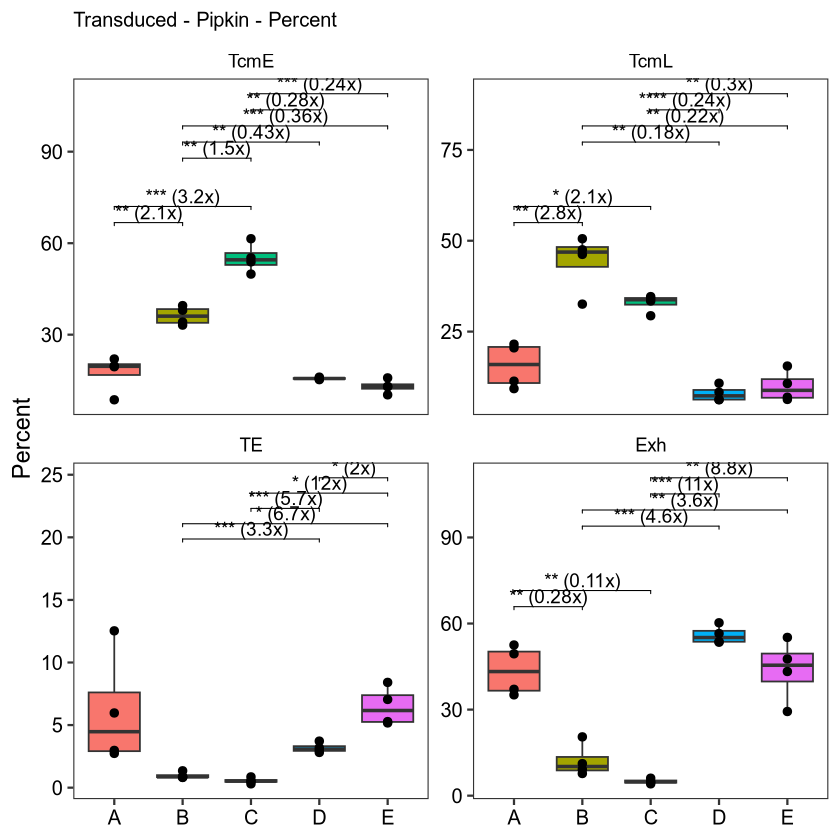

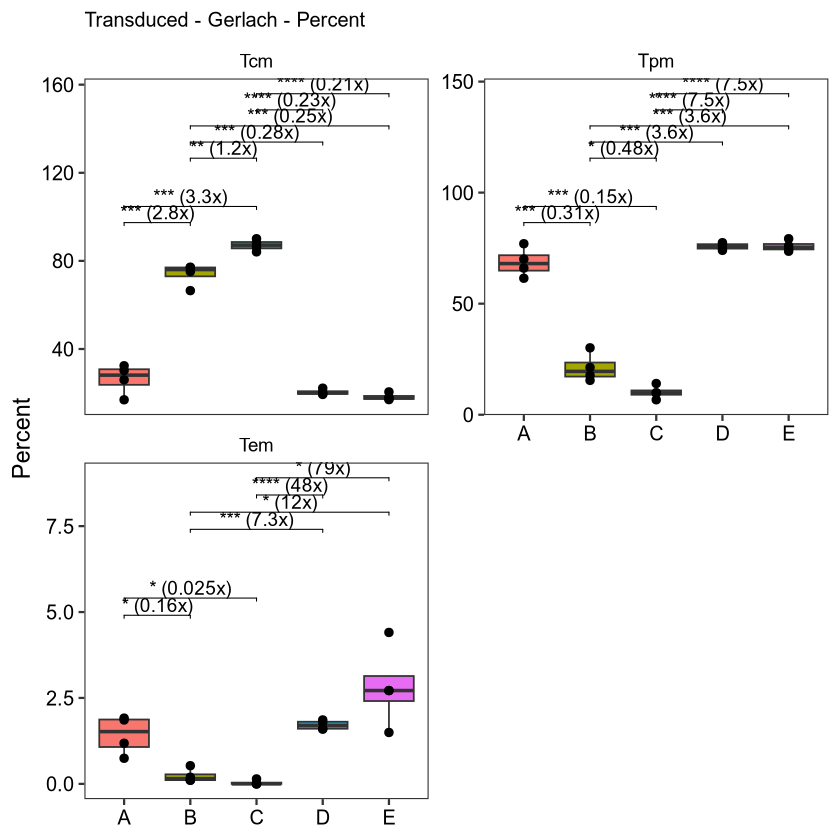

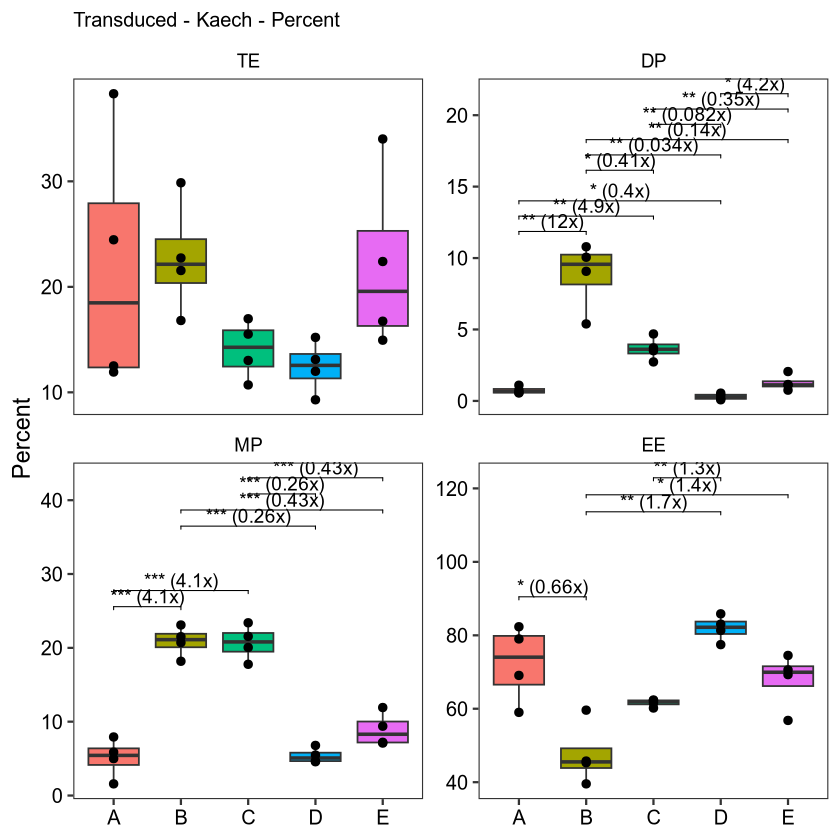

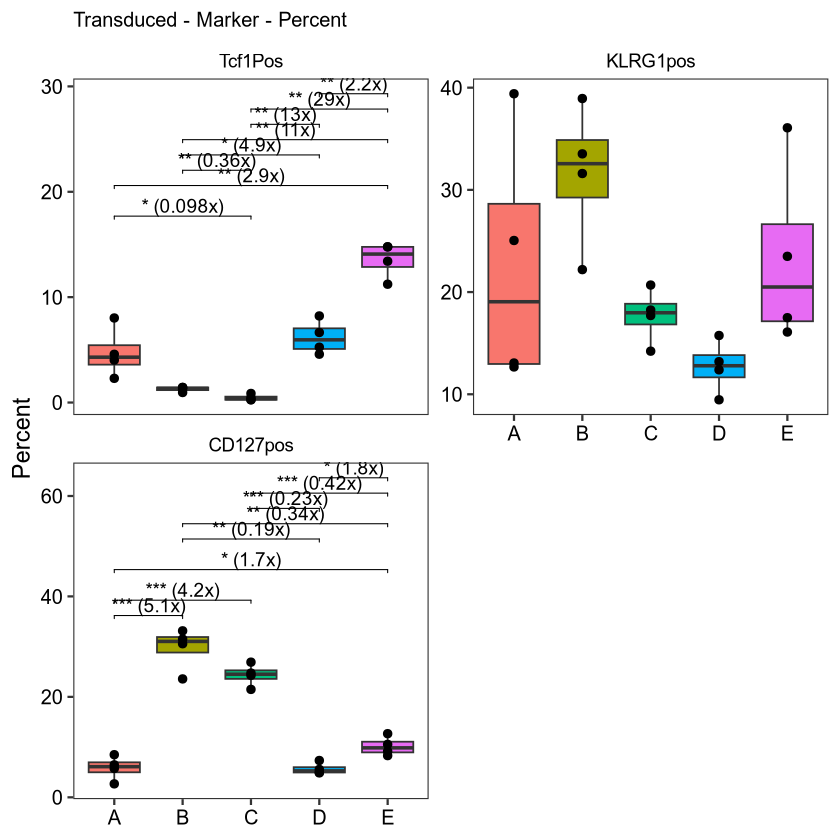

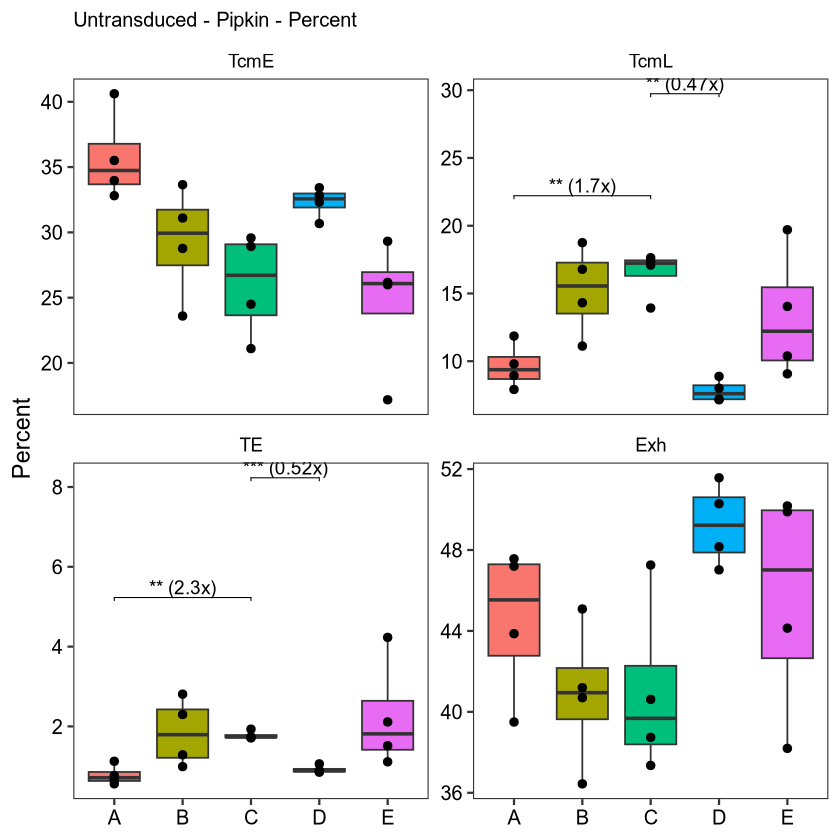

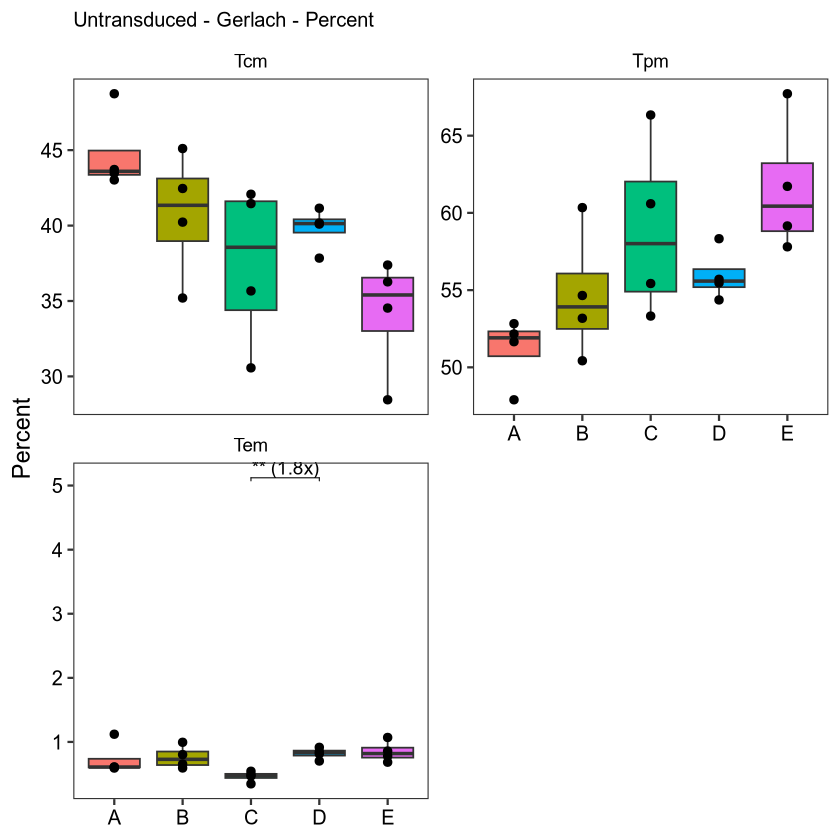

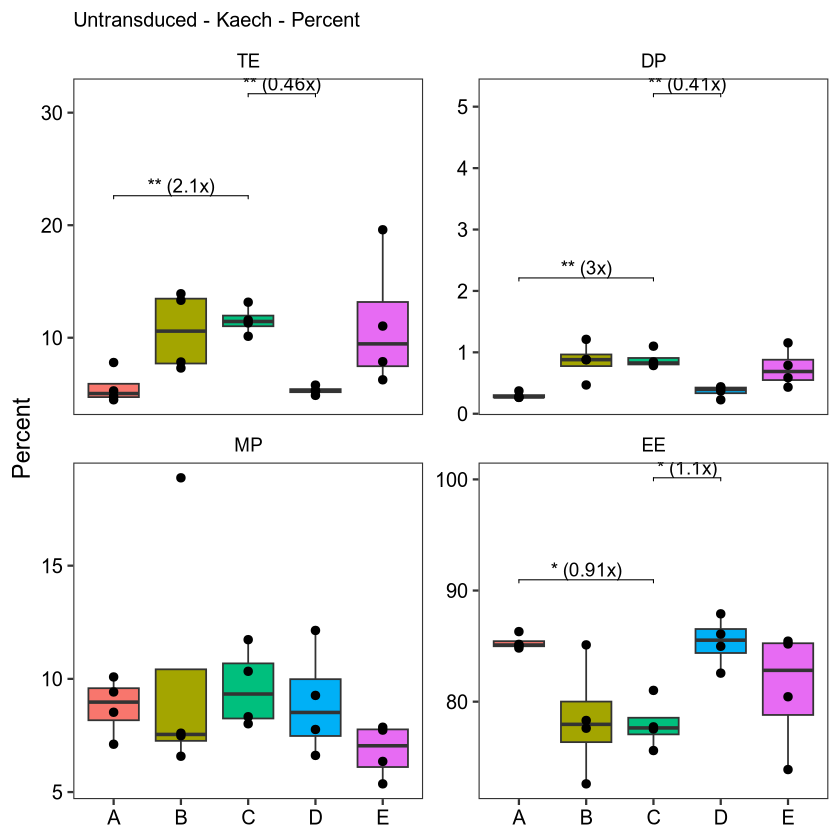

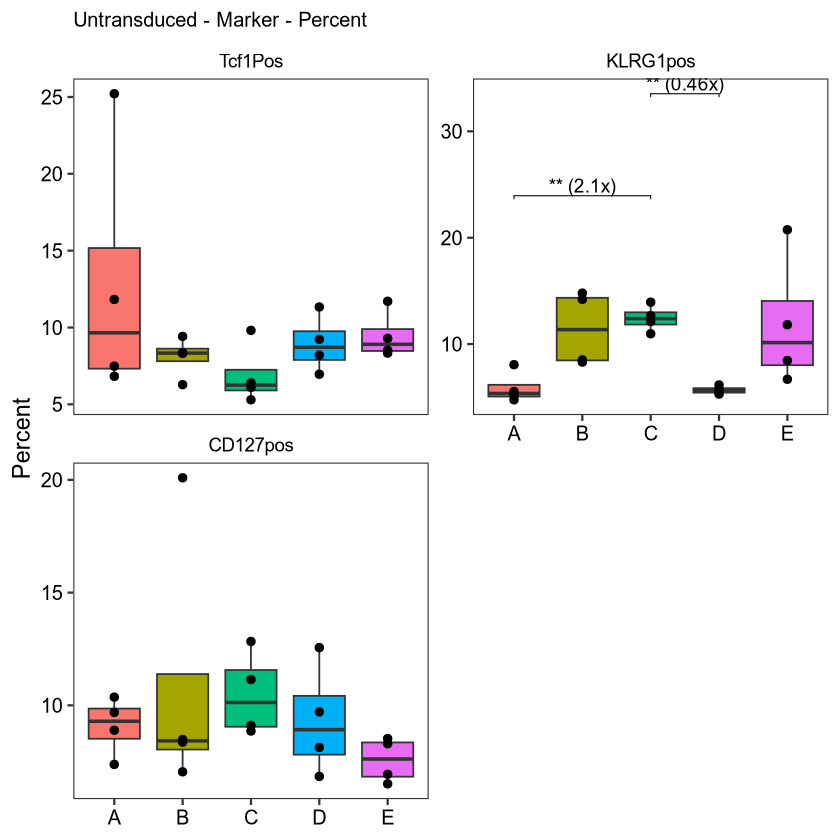

In [14]:
plotOnLoopPopulation <- function(transductions, p.schemas, y_axis, output_tag) {
    p.schemas.names <- names(p.schemas)

    # Loop on all transduction groups
    for(trans in transductions) {

        # Loop on all schemas on the Population level    
        for(schema in p.schemas.names) {

            # Select only Population with "Schema-" schema with no Population1Deriv
            # Keep only trans
            plot.data.df <- all.data %>%
                mutate(
                    Population = ifelse(Population == "all", "all-all",
                        ifelse(Population %in% c("CXCR6Pos", "ToxPos", "Tcf1Pos", "KLRG1pos", "CD127pos"), paste("Marker", Population, sep = "-"),
                            Population
                        )
                    )
                ) %>%
                filter(
                    Transduction == trans,
                    grepl(paste0(schema, "-"), Population)
                ) %>%
                mutate(
                    Population = factor( 
                        gsub(paste0(schema, "-"), "", Population),
                        levels = p.schemas[[schema]]
                    ),
                    Group = factor(Group, levels = d.schemas[["Group"]])
                ) %>% filter(!is.na(Population))  # Remove rows with NA Population after filtering
            
            # Calculate p-values and adjusted p-values for comparisons using plot_padj function
            # Skip this iteration gracefully if plot_padj fails
            plot.stat.df <- tryCatch(
                plot_padj(
                    data = plot.data.df,
                    comparisons = comparison_groups,
                    y_col = y_axis,
                    x_col = "Group",
                    facet_col = "Population",
                    step_fraction = 0.1,
                    min_step = 0.5
                ),
                error = function(e) {
                    message(sprintf(
                        "Skipping %s - %s - %s: plot_padj failed: %s",
                        trans, schema, output_tag, conditionMessage(e)
                    ))
                    NULL
                }
            )

            if (is.null(plot.stat.df)) {
                next
            }

            # Save plot.stat.df to a CSV file for inspection
            write.csv(plot.stat.df, paste0(
                output_folder,
                "/stats-",
                trans, "-", schema, "-", output_tag,
                ".csv"))

            # Round plot.stat.df column foldmean to one significant digit
            # Then concatenate to p.adj.signif only if not "ns", into column p.adj.fold
            plot.stat.df <- plot.stat.df %>%
                mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
                mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

            p <- ggplot(plot.data.df, aes(x = Group, y = .data[[y_axis]], fill = Group)) +
                geom_boxplot(outlier.shape = NA) +
                geom_point(size = 2) +
                facet_wrap(~Population, ncol = 2, scales = "free_y") +
                theme +
                stat_pvalue_manual(
                    plot.stat.df %>% filter(p.adj < 0.05),
                    label = "p.adj.fold",   # adjusted p-value stars
                    tip.length = 0.01,
                    size = 4,
                    inherit.aes = FALSE       # important fix
                ) + ggtitle(paste0(trans, " - ", schema, " - ", y_axis))

            print(p)

            ggsave(
                filename = paste0(
                    output_folder,
                    "/plots-",
                    trans, "-", schema, "-", output_tag,
                    ".pdf"),
                plot = p,
                width = 10,
                height = 10,
                units = "in"
            )

        }

    }

}

plotOnLoopPopulation(transductions, p.schemas, y_axis = "Percent", output_tag = "percentOFparents")

Skipping Transduced - Gerlach - TOXmfi: plot_padj failed: ℹ In argument: `data = map(.data$data, .f, ...)`.
Caused by error in `map()`:
ℹ In index: 2.
Caused by error in `map()`:
ℹ In index: 2.
Caused by error in `t.test.default()`:
! not enough 'y' observations



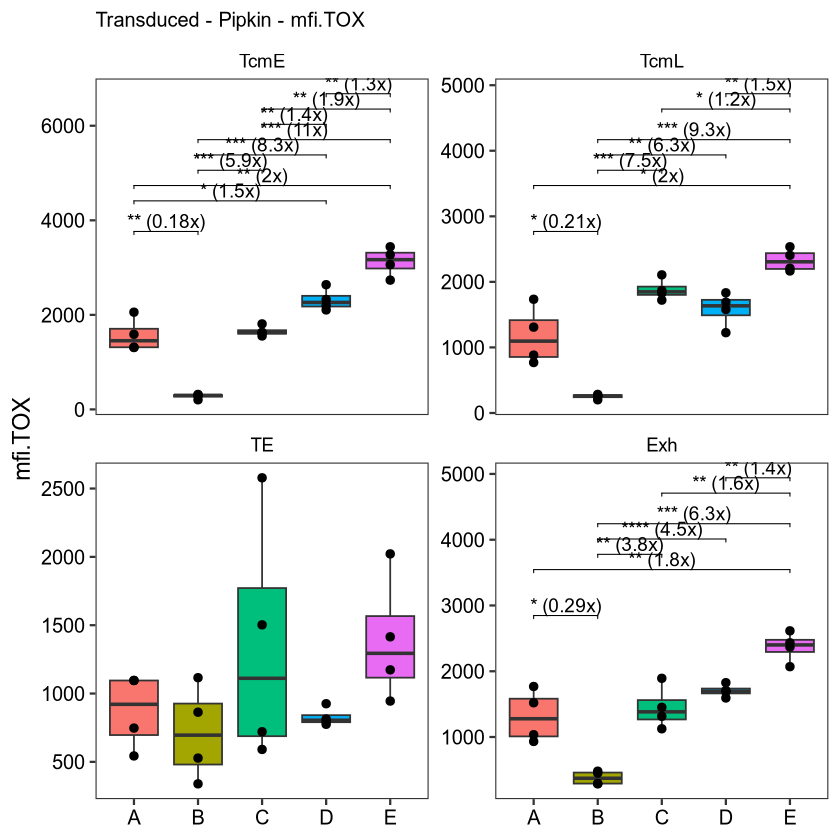

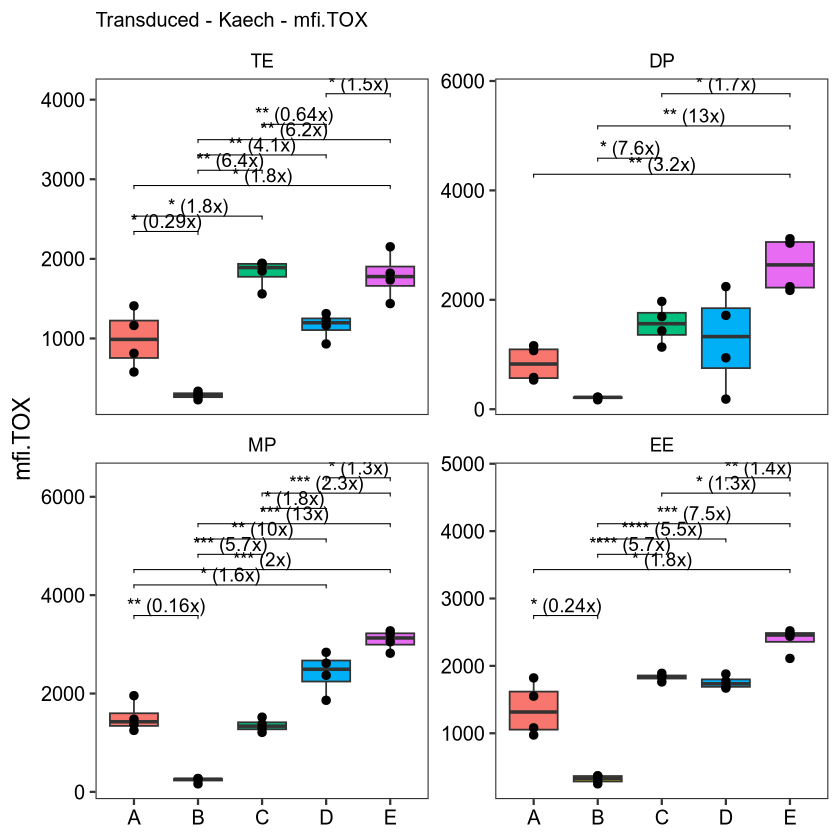

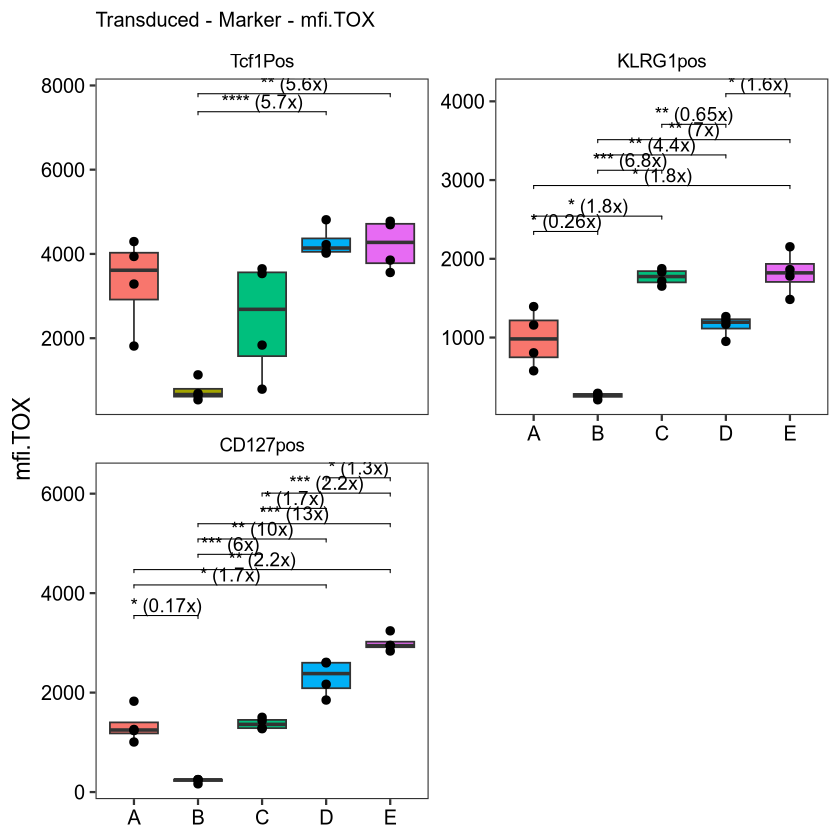

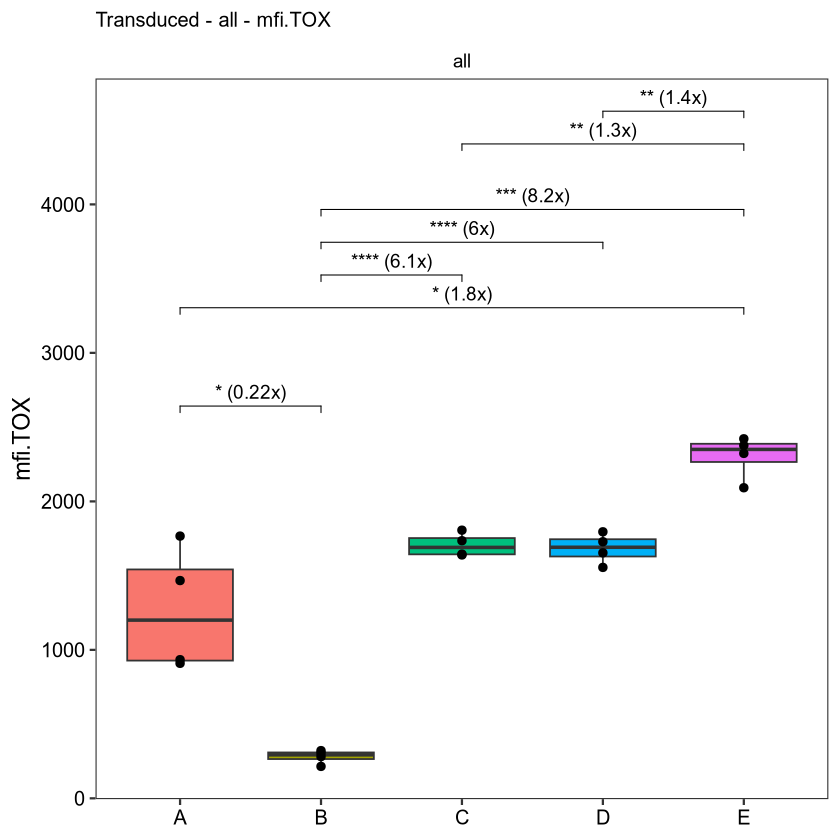

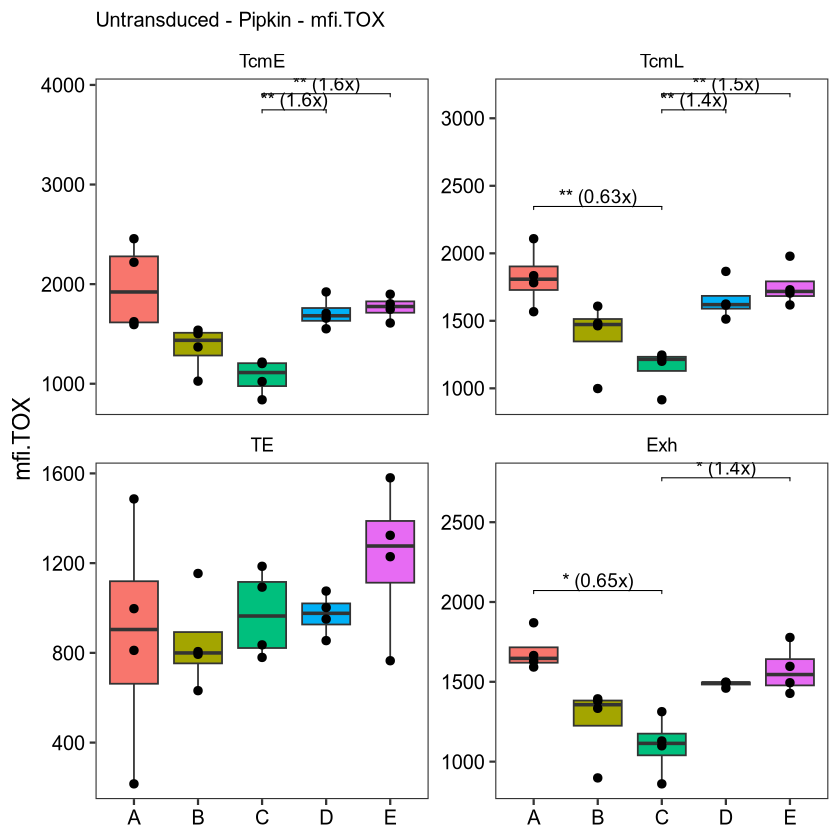

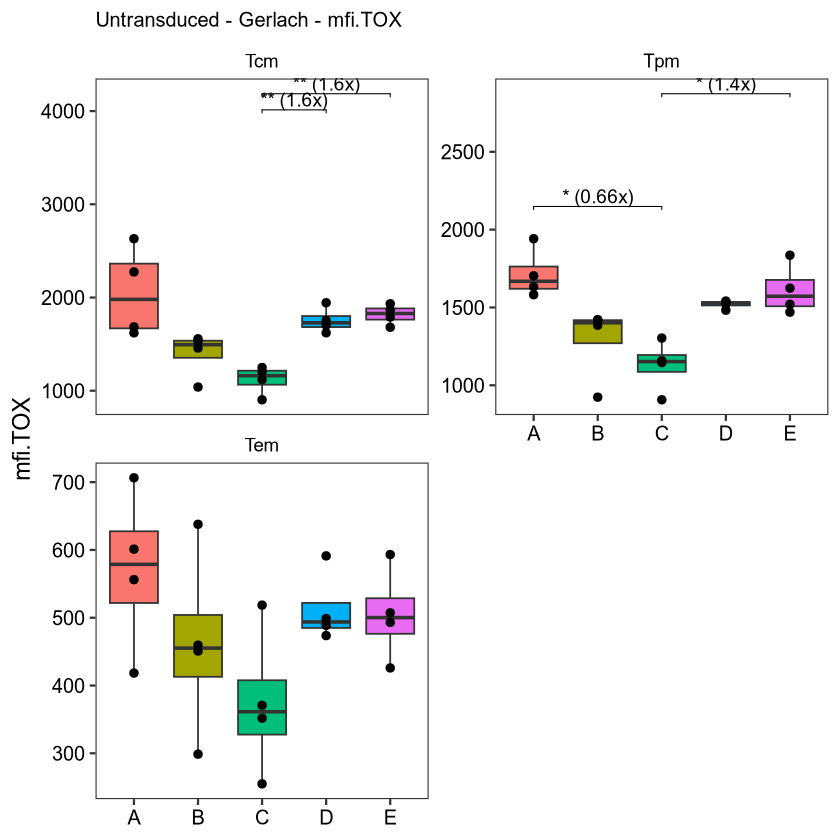

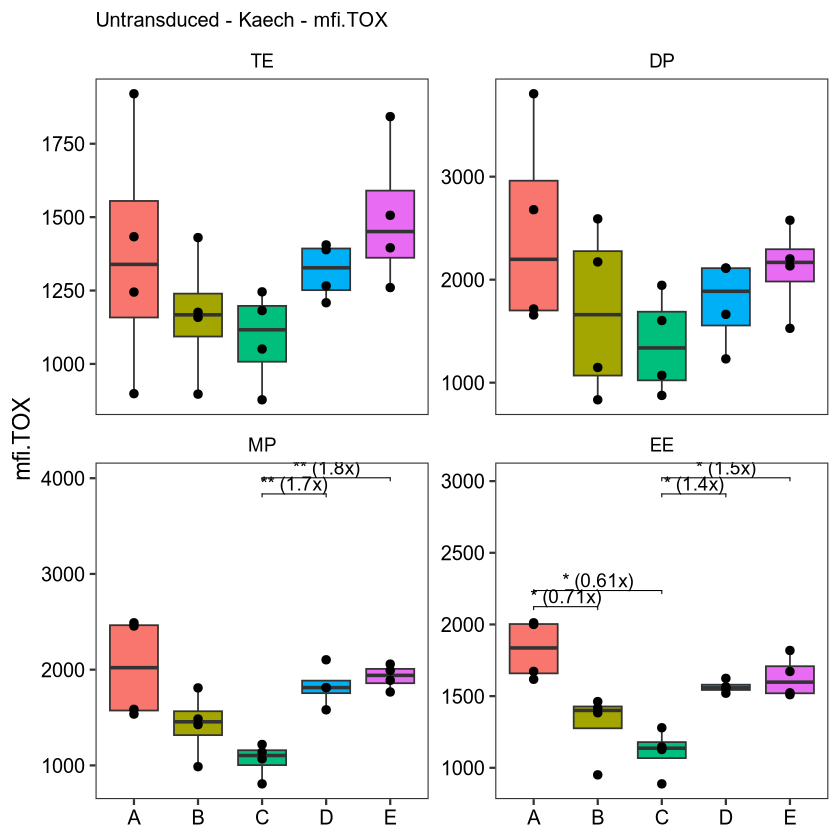

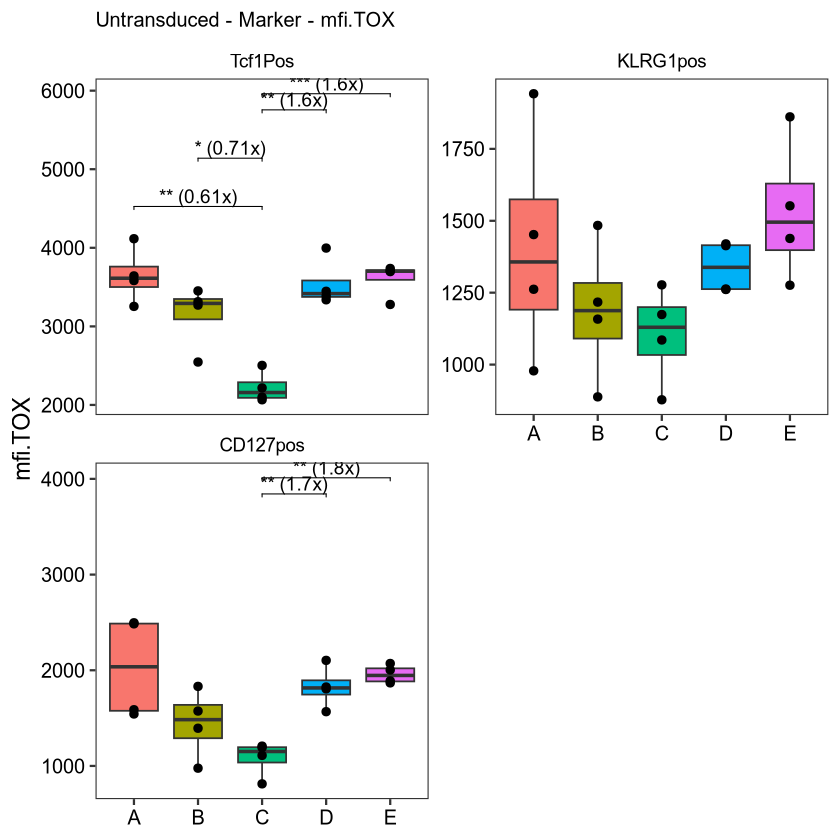

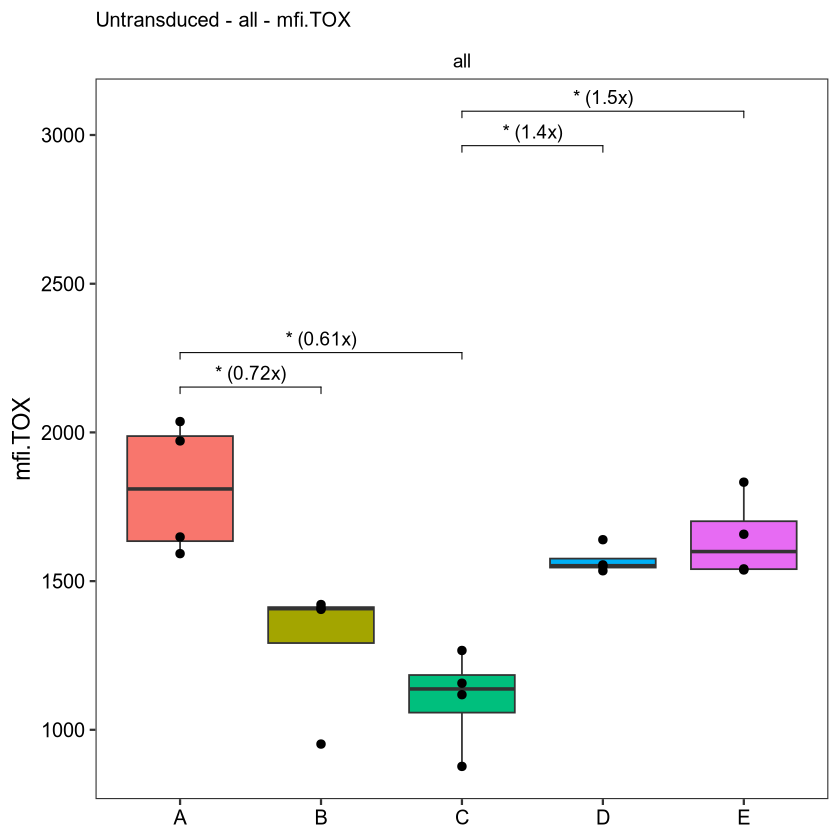

In [15]:
plotOnLoopPopulation(transductions, c(p.schemas, list(all = c("all"))), y_axis = "mfi.TOX", output_tag = "TOXmfi")

Skipping Transduced - Gerlach - PD1mfi: plot_padj failed: ℹ In argument: `data = map(.data$data, .f, ...)`.
Caused by error in `map()`:
ℹ In index: 2.
Caused by error in `map()`:
ℹ In index: 2.
Caused by error in `t.test.default()`:
! not enough 'y' observations



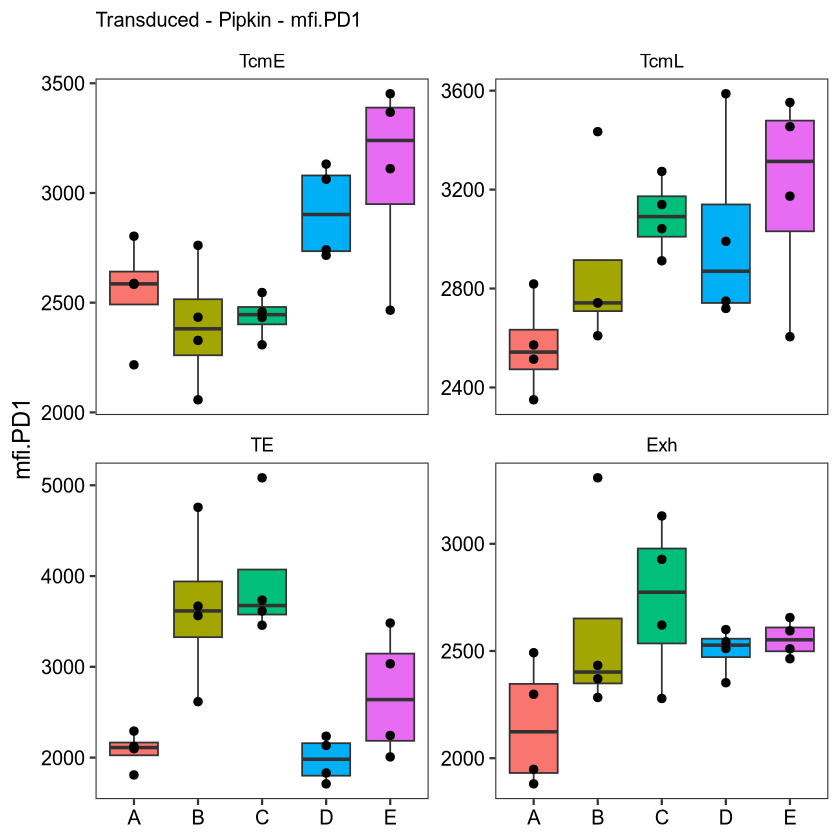

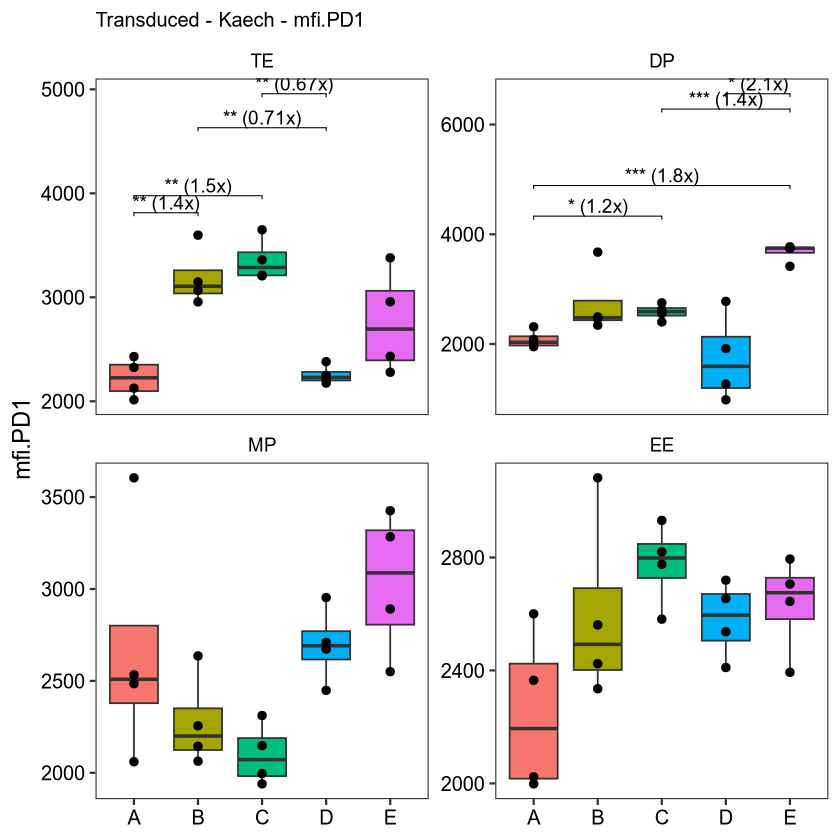

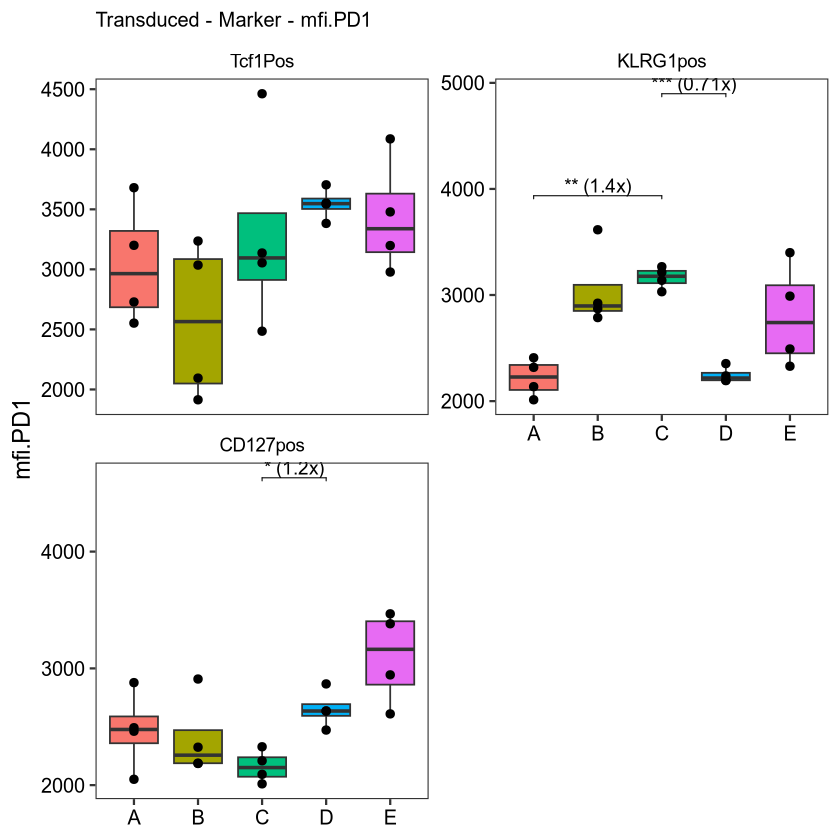

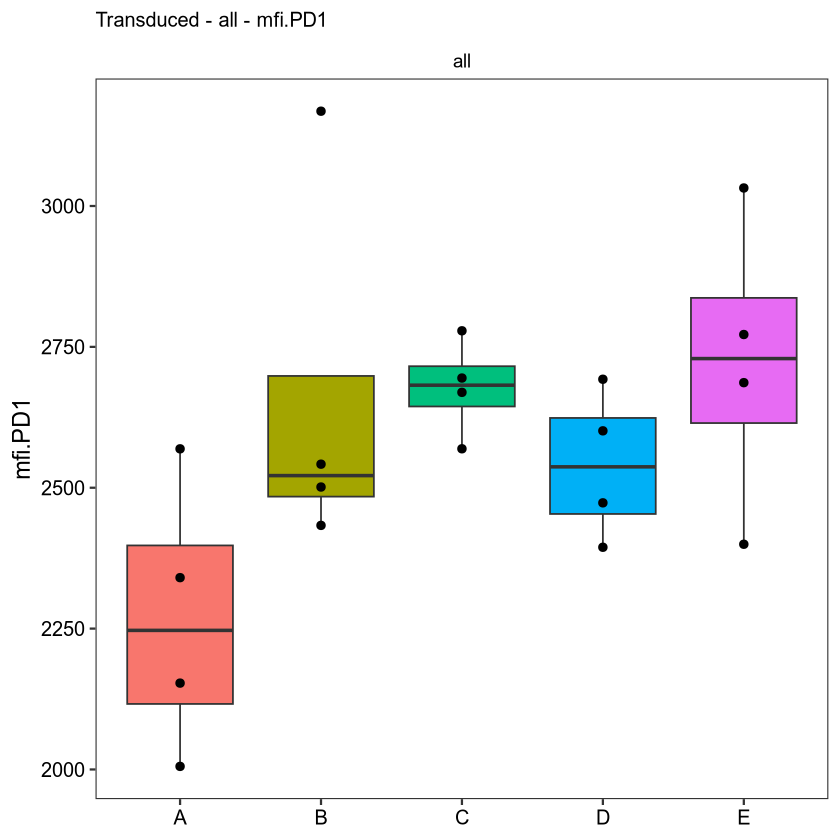

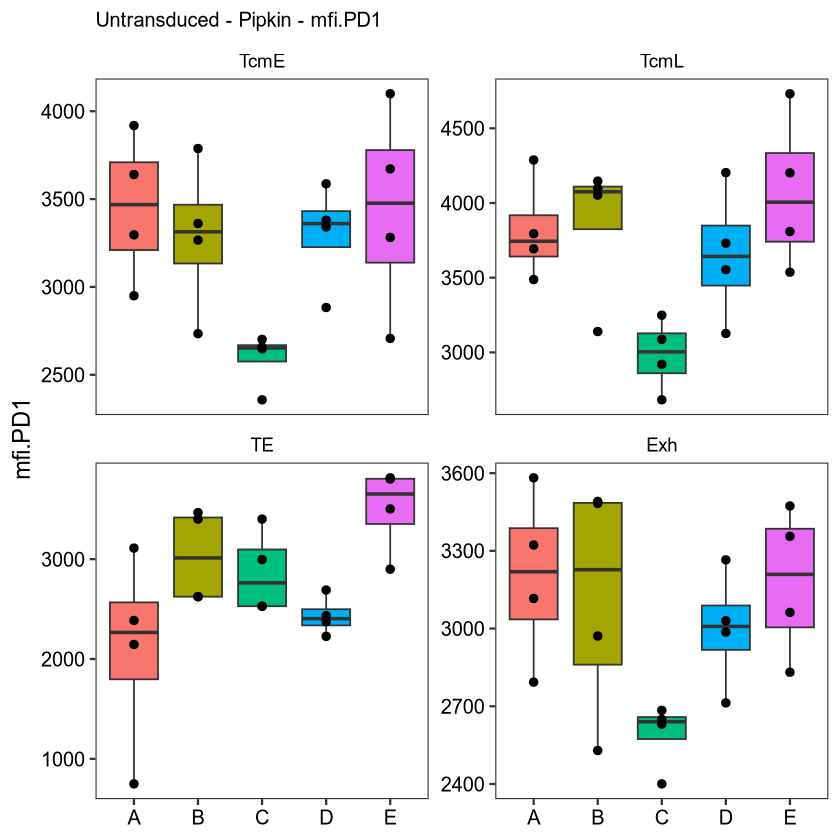

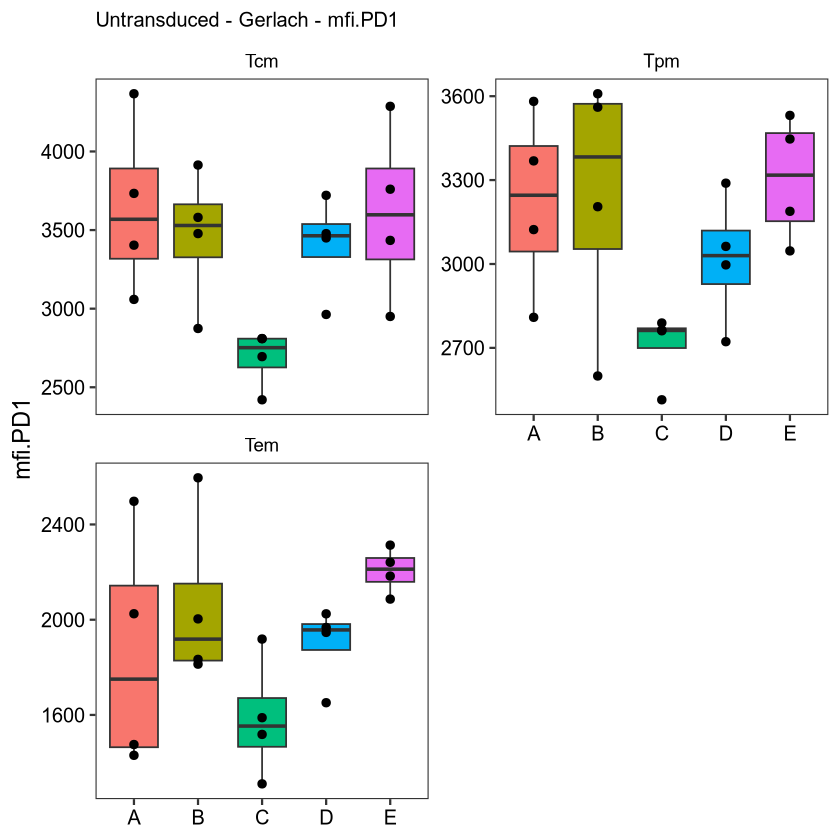

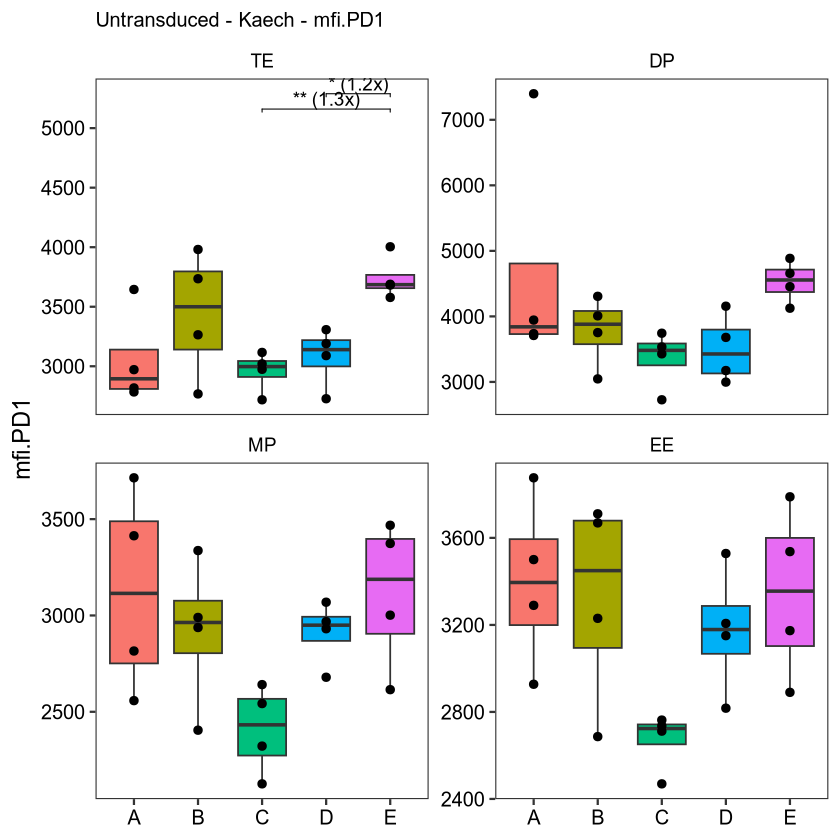

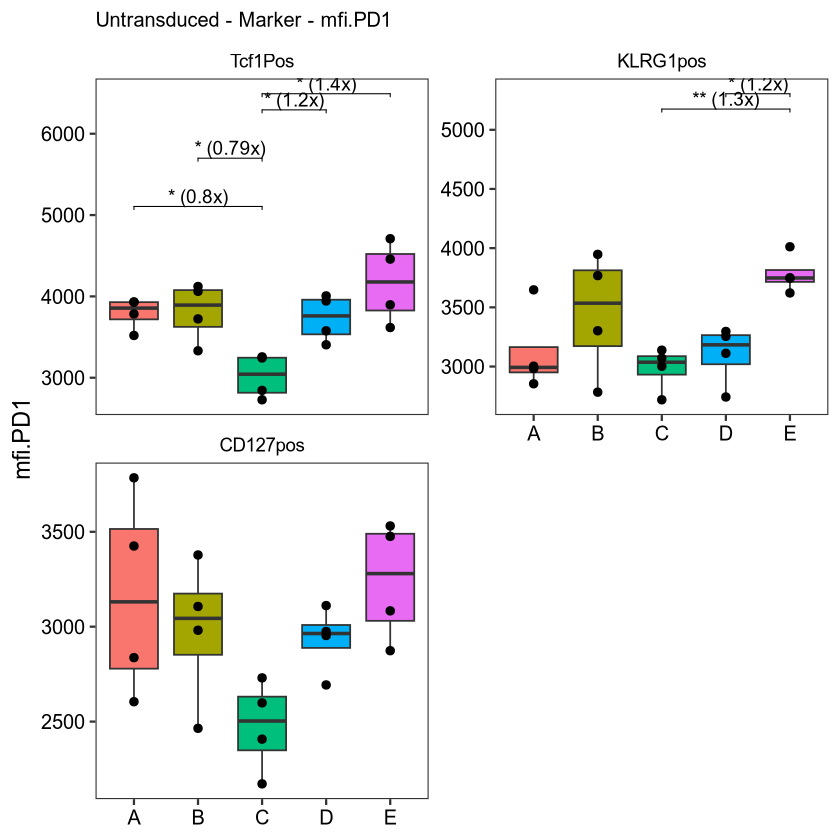

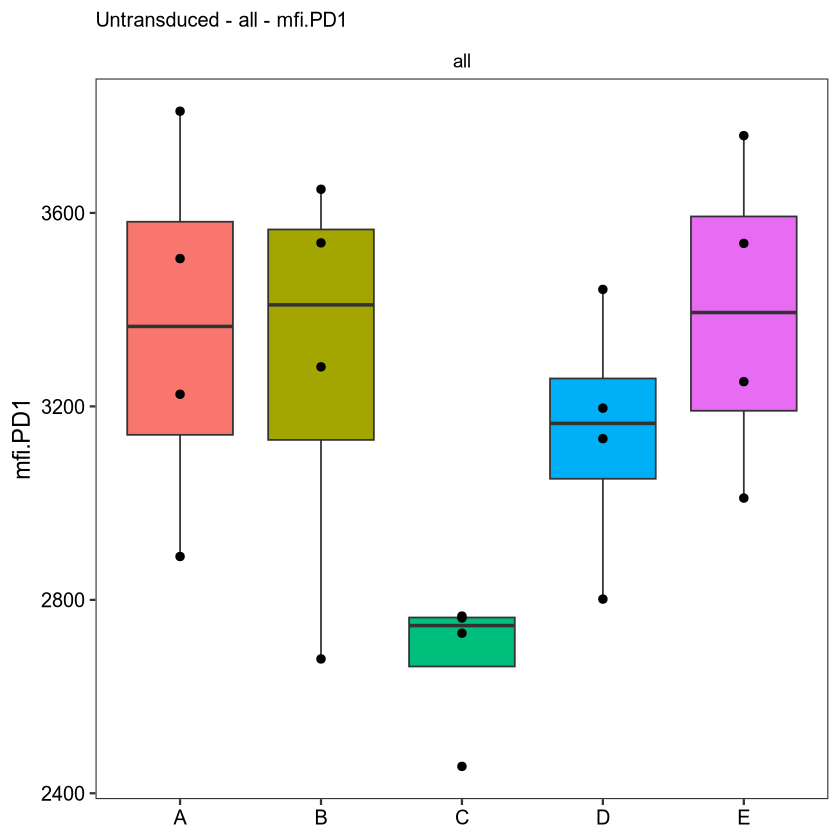

In [16]:
plotOnLoopPopulation(transductions, c(p.schemas, list(all = c("all"))), y_axis = "mfi.PD1", output_tag = "PD1mfi")

## D vs E, TOX MFI (Transduced vs Untransduced)

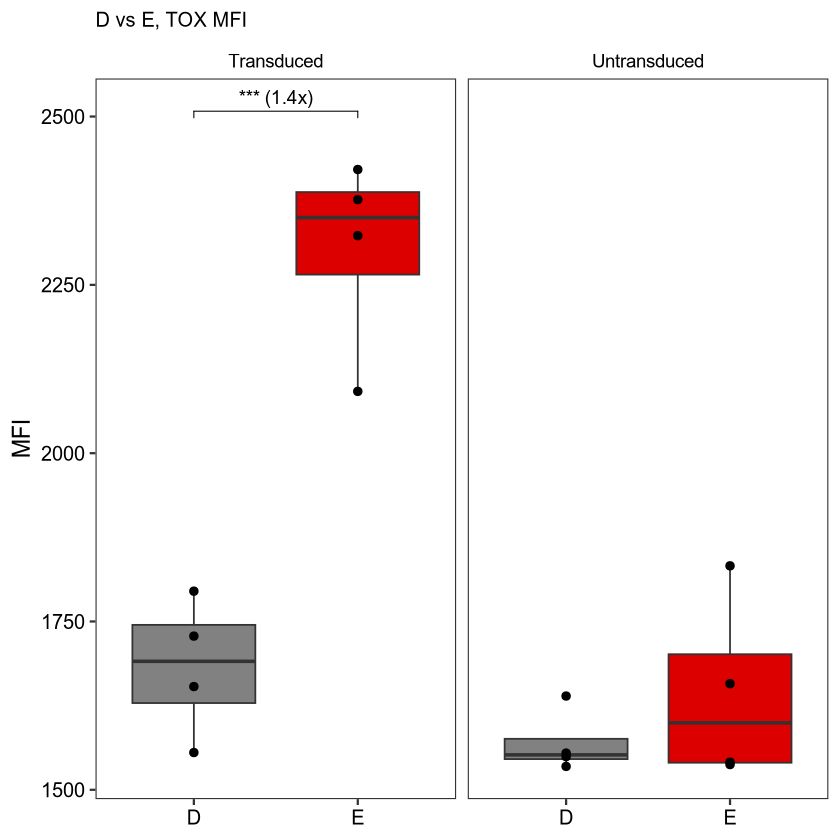

In [17]:
# Group colors: D = shCd19 (control), E = shRunx3 (knockdown)
de_colors <- c("D" = "#808180", "E" = "#DC0000")

de_tox <- all.data %>%
    filter(Population == "all", Group %in% c("D", "E")) %>%
    mutate(
        Group = factor(Group, levels = c("D", "E")),
        Transduction = factor(Transduction, levels = c("Transduced", "Untransduced"))
    )

# Unpaired comparison: D and E are different mice
plot.stat.df <- plot_padj(
    data = de_tox,
    comparisons = list(c("D", "E")),
    y_col = "mfi.TOX",
    x_col = "Group",
    facet_col = "Transduction",
    paired = FALSE,
    step_fraction = 0.1,
    min_step = 20
)

write.csv(plot.stat.df, paste0(output_folder, "/stats-DvsE-TOXmfi.csv"), row.names = FALSE)

# Round plot.stat.df column foldmean to one significant digit
# Then concatenate to p.adj.signif only if not "ns", into column p.adj.fold
plot.stat.df <- plot.stat.df %>%
    mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
    mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

p <- ggplot(de_tox, aes(x = Group, y = mfi.TOX, fill = Group)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 2) +
    facet_wrap(~Transduction) +
    scale_fill_manual(values = de_colors) +
    theme +
    stat_pvalue_manual(
        plot.stat.df %>% filter(p.adj < 0.05),
        label = "p.adj.fold",
        tip.length = 0.01,
        size = 4,
        inherit.aes = FALSE
    ) +
    ylab("MFI") + ggtitle("D vs E, TOX MFI")

print(p)

ggsave(
    filename = paste0(output_folder, "/plots-DvsE-TOXmfi.pdf"),
    plot = p,
    width = 5,
    height = 4,
    units = "in"
)

## A vs B vs C, Transduced only (EE/KLRG1+/CD127+ and Pipkin CX3CR1-staging subsets)

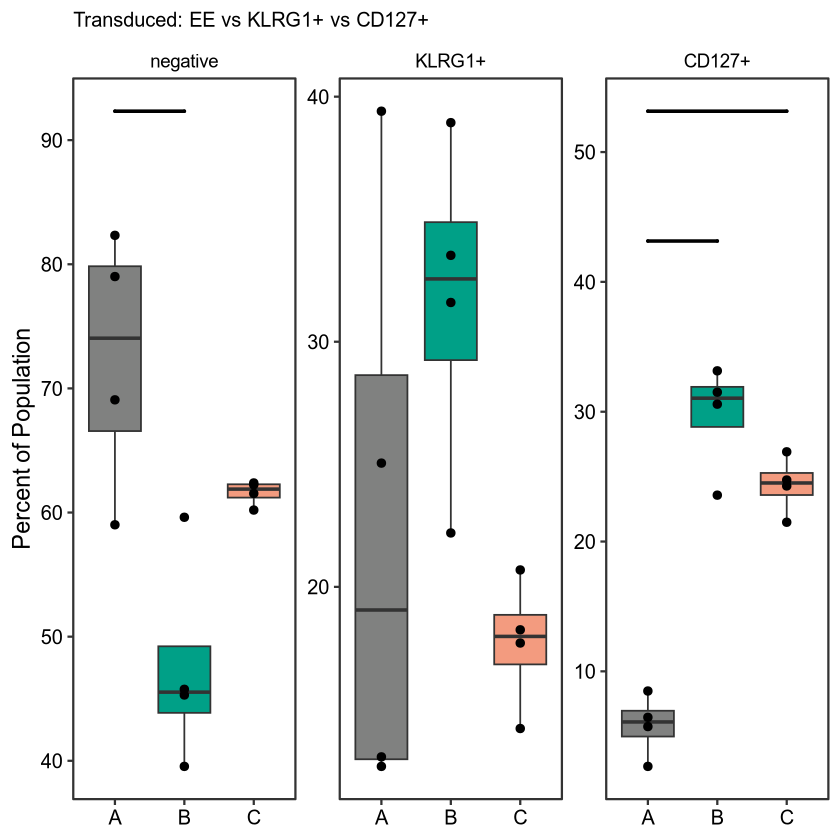

In [18]:
# Group colors: A = mock, B = Runx3-WT, C = Runx3-dID
abc_colors <- c("A" = "#808180", "B" = "#00A087", "C" = "#F39B7F")
abc_comparisons <- list(c("A", "B"), c("A", "C"), c("B", "C"))

# EE (renamed "negative") vs KLRG1+ vs CD127+, Transduced only
kaech_reduced <- all.data %>%
    filter(
        Transduction == "Transduced",
        Group %in% c("A", "B", "C"),
        Population %in% c("Kaech-EE", "KLRG1pos", "CD127pos")
    ) %>%
    mutate(
        Population = factor(
            recode(Population, "Kaech-EE" = "negative", "KLRG1pos" = "KLRG1+", "CD127pos" = "CD127+"),
            levels = c("negative", "KLRG1+", "CD127+")
        ),
        Group = factor(Group, levels = c("A", "B", "C"))
    )

# Unpaired comparison: A/B/C are different mice
plot.stat.df <- plot_padj(
    data = kaech_reduced,
    comparisons = abc_comparisons,
    y_col = "Percent",
    x_col = "Group",
    facet_col = "Population",
    paired = FALSE,
    step_fraction = 0.15,
    min_step = 10
)

write.csv(plot.stat.df, paste0(output_folder, "/stats-Transduced-ABC-Kaech-Reduced.csv"), row.names = FALSE)

plot.stat.df <- plot.stat.df %>%
    mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
    mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

p <- ggplot(kaech_reduced, aes(x = Group, y = Percent, fill = Group)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 2) +
    facet_wrap(~Population, scales = "free_y") +
    scale_fill_manual(values = abc_colors) +
    coord_cartesian(clip = "off") +
    theme +
    stat_pvalue_manual(
        plot.stat.df %>% filter(p.adj < 0.05) %>% mutate(blank = ""),
        label = "blank",
        tip.length = 0,
        bracket.size = 1,
        inherit.aes = FALSE
    ) +
    ylab("Percent of Population") + ggtitle("Transduced: EE vs KLRG1+ vs CD127+")

print(p)

ggsave(
    filename = paste0(output_folder, "/plots-Transduced-ABC-Kaech-Reduced.pdf"),
    plot = p,
    width = 5.5,
    height = 4,
    units = "in"
)

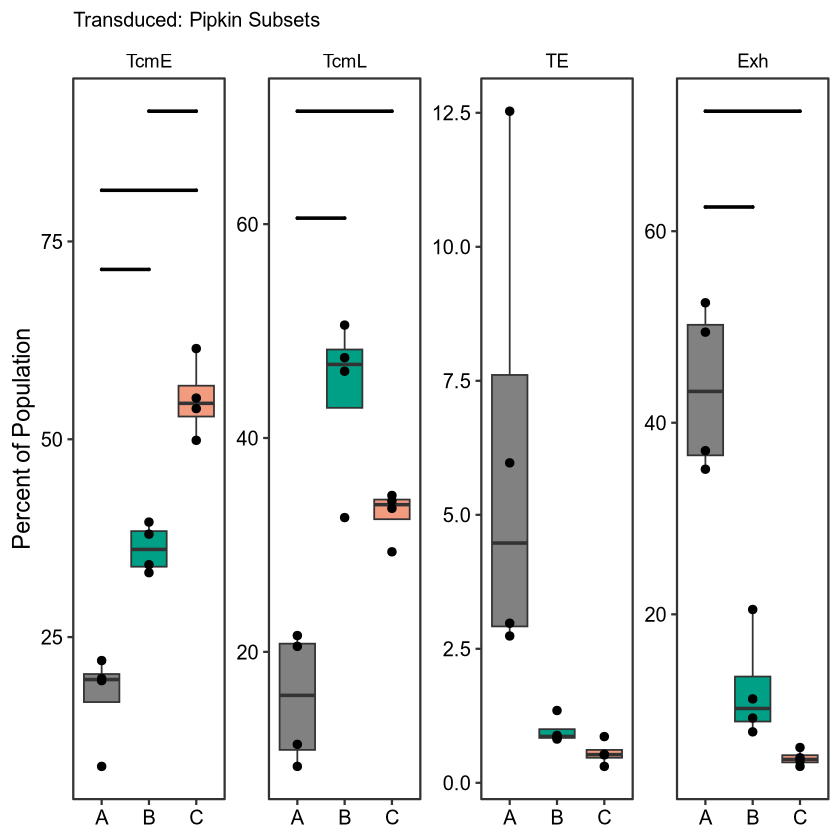

In [19]:
# Pipkin subsets (TcmE/TcmL/TE/Exh): Diva01's CX3CR1-staging equivalent of
# 2022-001's TcmKLRG1/NonterminalKLRG1/TerminalKLRG1/ExhKLRG1 subsets
pipkin_reduced <- all.data %>%
    filter(
        Transduction == "Transduced",
        Group %in% c("A", "B", "C"),
        grepl("^Pipkin-", Population)
    ) %>%
    mutate(
        Population = factor(gsub("^Pipkin-", "", Population), levels = p.schemas[["Pipkin"]]),
        Group = factor(Group, levels = c("A", "B", "C"))
    )

# Unpaired comparison: A/B/C are different mice
plot.stat.df <- plot_padj(
    data = pipkin_reduced,
    comparisons = abc_comparisons,
    y_col = "Percent",
    x_col = "Group",
    facet_col = "Population",
    paired = FALSE,
    step_fraction = 0.15,
    min_step = 10
)

write.csv(plot.stat.df, paste0(output_folder, "/stats-Transduced-ABC-Pipkin-Reduced.csv"), row.names = FALSE)

plot.stat.df <- plot.stat.df %>%
    mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
    mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

p <- ggplot(pipkin_reduced, aes(x = Group, y = Percent, fill = Group)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 2) +
    facet_wrap(~Population, ncol = 4, scales = "free_y") +
    scale_fill_manual(values = abc_colors) +
    coord_cartesian(clip = "off") +
    theme +
    stat_pvalue_manual(
        plot.stat.df %>% filter(p.adj < 0.05) %>% mutate(blank = ""),
        label = "blank",
        tip.length = 0,
        bracket.size = 1,
        inherit.aes = FALSE
    ) +
    ylab("Percent of Population") + ggtitle("Transduced: Pipkin Subsets")

print(p)

ggsave(
    filename = paste0(output_folder, "/plots-Transduced-ABC-Pipkin-Reduced.pdf"),
    plot = p,
    width = 5.5,
    height = 4,
    units = "in"
)

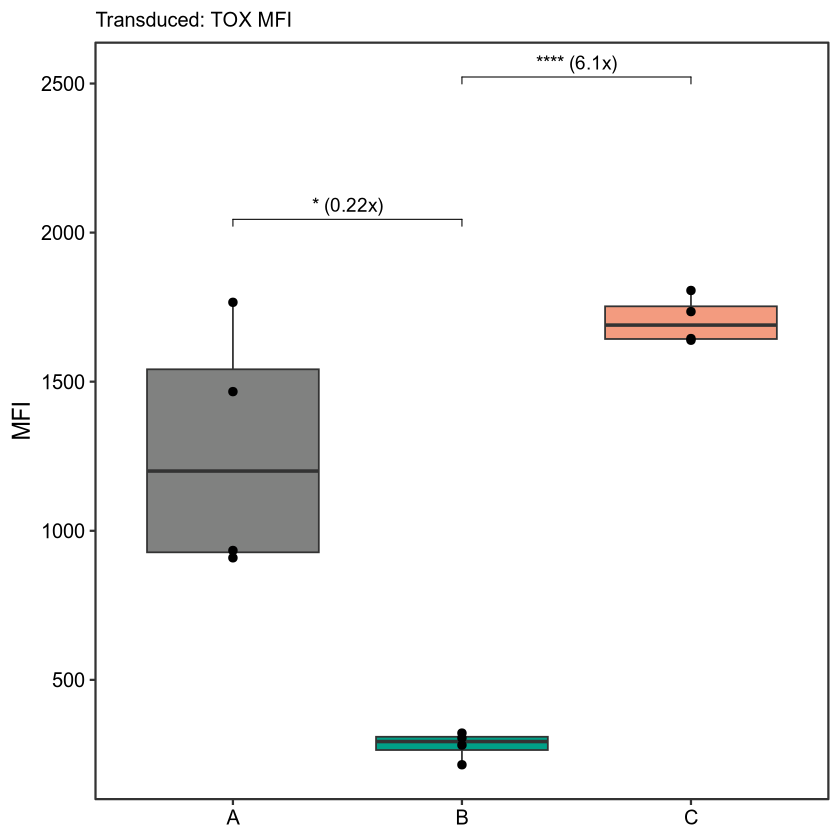

In [20]:
# TOX MFI by A/B/C, Transduced only
abc_tox <- all.data %>%
    filter(Transduction == "Transduced", Group %in% c("A", "B", "C"), Population == "all") %>%
    mutate(Group = factor(Group, levels = c("A", "B", "C")))

# Unpaired comparison: A/B/C are different mice
plot.stat.df <- plot_padj(
    data = abc_tox,
    comparisons = abc_comparisons,
    y_col = "mfi.TOX",
    x_col = "Group",
    paired = FALSE,
    step_fraction = 0.15,
    min_step = 20
)

write.csv(plot.stat.df, paste0(output_folder, "/stats-Transduced-ABC-TOXmfi.csv"), row.names = FALSE)

plot.stat.df <- plot.stat.df %>%
    mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
    mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

p <- ggplot(abc_tox, aes(x = Group, y = mfi.TOX, fill = Group)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 2) +
    scale_fill_manual(values = abc_colors) +
    coord_cartesian(clip = "off") +
    theme +
    stat_pvalue_manual(
        plot.stat.df %>% filter(p.adj < 0.05),
        label = "p.adj.fold",
        tip.length = 0.01,
        size = 4,
        inherit.aes = FALSE
    ) +
    ylab("MFI") + ggtitle("Transduced: TOX MFI")

print(p)

ggsave(
    filename = paste0(output_folder, "/plots-Transduced-ABC-TOXmfi.pdf"),
    plot = p,
    width = 5.5,
    height = 4,
    units = "in"
)